In [1]:
import os
from pathlib import Path
import shutil

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("himelsarder/coffee-shop-daily-revenue-prediction-dataset")

path = Path(path)
print("Path to dataset files:", path)

100%|██████████| 29.5k/29.5k [00:00<00:00, 22.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/himelsarder/coffee-shop-daily-revenue-prediction-dataset/versions/1


In [3]:
os.getcwd()

'/content'

In [4]:
os.mkdir("dataset")

In [5]:
os.listdir()

['.config', 'dataset', 'sample_data']

In [6]:
os.listdir(path)

['coffee_shop_revenue.csv']

In [7]:
path

PosixPath('/root/.cache/kagglehub/datasets/himelsarder/coffee-shop-daily-revenue-prediction-dataset/versions/1')

In [8]:
source_directory = path / "coffee_shop_revenue.csv"
destination_directory = "/content/dataset"

In [9]:
shutil.copy(source_directory, destination_directory)

'/content/dataset/coffee_shop_revenue.csv'

In [10]:
root_dir = Path("/content/dataset")
os.listdir(root_dir)

['coffee_shop_revenue.csv']

In [11]:
import pandas as pd

In [12]:
original_df = pd.read_csv(root_dir / "coffee_shop_revenue.csv")
df = original_df.copy()
df.head(10)

,Number_of_Customers_Per_Day,Average_Order_Value,Operating_Hours_Per_Day,Number_of_Employees,Marketing_Spend_Per_Day,Location_Foot_Traffic,Daily_Revenue
0,152,6.74,14,4,106.62,97,1547.81
1,485,4.50,12,8,57.83,744,2084.68
2,398,9.09,6,6,91.76,636,3118.39
3,320,8.48,17,4,462.63,770,2912.20
4,156,7.44,17,2,412.52,232,1663.42
5,121,8.88,6,9,183.49,484,1155.18
6,238,9.00,11,4,331.35,156,2179.13
7,70,7.81,10,3,273.27,237,890.17
8,152,8.78,14,2,341.79,825,1704.94
9,171,7.73,7,5,344.51,135,2025.55


In [13]:
df.shape

(2000, 7)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.isnull().sum()

,0
Number_of_Customers_Per_Day,0
Average_Order_Value,0
Operating_Hours_Per_Day,0
Number_of_Employees,0
Marketing_Spend_Per_Day,0
Location_Foot_Traffic,0
Daily_Revenue,0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Number_of_Customers_Per_Day  2000 non-null   int64  
 1   Average_Order_Value          2000 non-null   float64
 2   Operating_Hours_Per_Day      2000 non-null   int64  
 3   Number_of_Employees          2000 non-null   int64  
 4   Marketing_Spend_Per_Day      2000 non-null   float64
 5   Location_Foot_Traffic        2000 non-null   int64  
 6   Daily_Revenue                2000 non-null   float64
dtypes: float64(3), int64(4)
memory usage: 109.5 KB


In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Number_of_Customers_Per_Day,2000.0,274.296000,129.441933,50.00,164.000,275.000,386.0000,499.00
Average_Order_Value,2000.0,6.261215,2.175832,2.50,4.410,6.300,8.1200,10.00
Operating_Hours_Per_Day,2000.0,11.667000,3.438608,6.00,9.000,12.000,15.0000,17.00
Number_of_Employees,2000.0,7.947000,3.742218,2.00,5.000,8.000,11.0000,14.00
Marketing_Spend_Per_Day,2000.0,252.614160,141.136004,10.12,130.125,250.995,375.3525,499.74
Location_Foot_Traffic,2000.0,534.893500,271.662295,50.00,302.000,540.000,767.0000,999.00
Daily_Revenue,2000.0,1917.325940,976.202746,-58.95,1140.085,1770.775,2530.4550,5114.60


In [18]:
import matplotlib.pyplot as plt

In [20]:
df.columns

Index(['Number_of_Customers_Per_Day', 'Average_Order_Value',
       'Operating_Hours_Per_Day', 'Number_of_Employees',
       'Marketing_Spend_Per_Day', 'Location_Foot_Traffic', 'Daily_Revenue'],
      dtype='object')

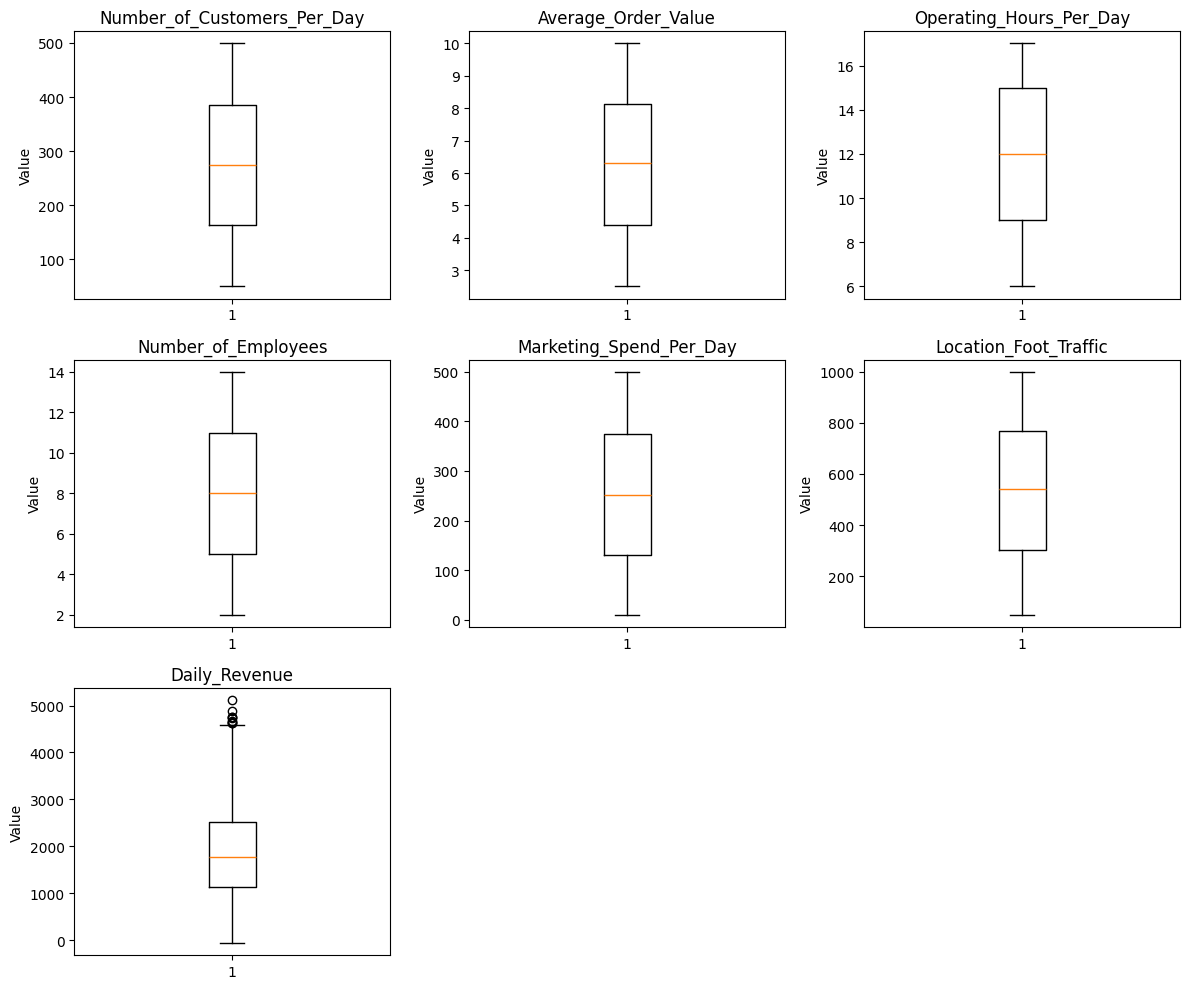

In [24]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for ax, column in zip(axes, df.columns):
    ax.boxplot(df[column])
    ax.set_title(column)
    ax.set_ylabel("Value")

for ax in axes[len(df.columns):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

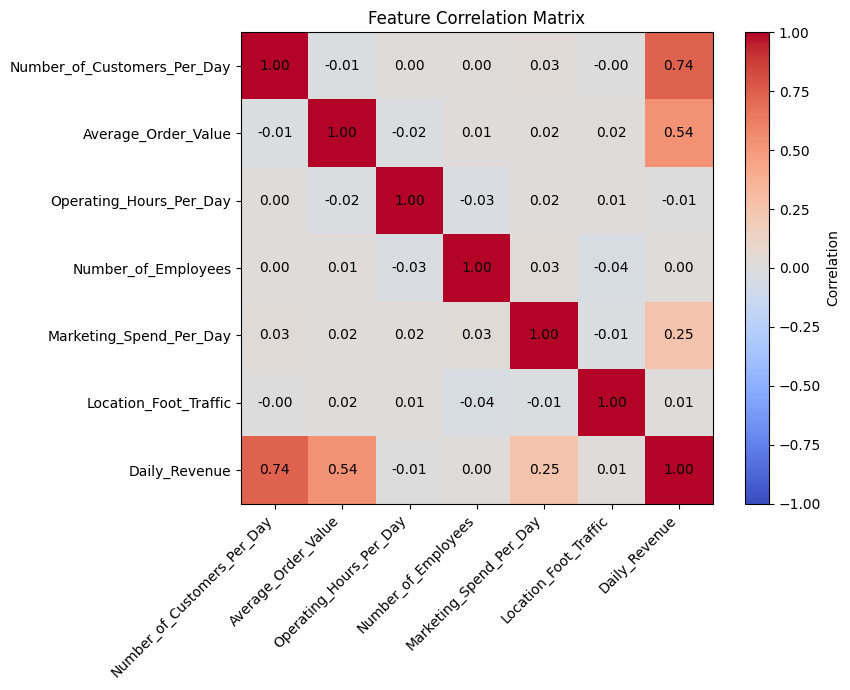

,Daily_Revenue
Daily_Revenue,1.000000
Number_of_Customers_Per_Day,0.736461
Average_Order_Value,0.535694
Marketing_Spend_Per_Day,0.254812
Location_Foot_Traffic,0.013469
Number_of_Employees,0.003295
Operating_Hours_Per_Day,-0.005323


In [25]:
corr = df.corr(numeric_only=True)

fig, corr_ax = plt.subplots(figsize=(9, 7))
image = corr_ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

corr_ax.set_xticks(range(len(corr.columns)))
corr_ax.set_xticklabels(corr.columns, rotation=45, ha="right")
corr_ax.set_yticks(range(len(corr.columns)))
corr_ax.set_yticklabels(corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        corr_ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

corr_ax.set_title("Feature Correlation Matrix")
fig.colorbar(image, ax=corr_ax, label="Correlation")
plt.tight_layout()
plt.show()

# Correlations of every feature with Daily_Revenue
corr["Daily_Revenue"].sort_values(ascending=False)

In [27]:
new_df = df.drop(['Operating_Hours_Per_Day', 'Number_of_Employees', 'Location_Foot_Traffic'], axis=1)
new_df.head()

,Number_of_Customers_Per_Day,Average_Order_Value,Marketing_Spend_Per_Day,Daily_Revenue
0,152,6.74,106.62,1547.81
1,485,4.50,57.83,2084.68
2,398,9.09,91.76,3118.39
3,320,8.48,462.63,2912.20
4,156,7.44,412.52,1663.42


In [28]:
root_dir

PosixPath('/content/dataset')

In [29]:
os.listdir(root_dir)

['coffee_shop_revenue.csv']

In [30]:
new_df.to_csv("coffee_shop_dataset.csv", index=False)
print("Saved Successfully!")

Saved Successfully!
